In [1]:
# ======================================
# 1. 导入依赖库
# ======================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from imblearn.over_sampling import SMOTE  # 数据平衡
import rdkit
from rdkit.Chem import AllChem
from rdkit import Chem
import warnings
import os
import shap
import matplotlib.pyplot as plt  # SHAP可视化
warnings.filterwarnings("ignore")

from mordred import Calculator, descriptors
from rdkit.Chem import MolFromSmiles

# 全局Mordred计算器（只创建一次，大幅提速）
calc = Calculator(descriptors, ignore_3D=True)

# 设置随机种子（保证结果可复现）
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ======================================

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
# 2. 数据预处理工具函数
# ======================================
def get_toxicity_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(1613, dtype=np.float32)  # Mordred 2D固定维度1613
    
    desc = calc(mol)
    desc = desc.fill_missing(0)
    desc_array = np.array(desc, dtype=np.float32)
    desc_array[np.isinf(desc_array)] = 0
    return desc_array

def map_species_to_id(species_list):
    unique_species = sorted(list(set(species_list)))
    species2id = {s: i for i, s in enumerate(unique_species)}
    species_ids = np.array([species2id[s] for s in species_list])
    return species_ids, species2id

# ======================================

In [3]:
# 3. 自定义数据集类
# ======================================
class ToxicityDataset(Dataset):
    def __init__(self, compound_features, species_ids, labels):
        self.compound_features = torch.tensor(compound_features, dtype=torch.float32)
        self.species_ids = torch.tensor(species_ids, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.compound_features[idx], self.species_ids[idx], self.labels[idx]

In [4]:
# 4. 定义MLP模型
# ======================================
class ReproductiveToxicityMLP(nn.Module):
    def __init__(self, compound_dim, n_species=10, species_emb_dim=16, hidden_dims=[128, 64]):
        super().__init__()
        self.species_emb = nn.Embedding(num_embeddings=n_species, embedding_dim=species_emb_dim)
        input_dim = compound_dim + species_emb_dim
        
        layers = []
        prev_dim = input_dim
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            layers.append(nn.LeakyReLU(0.1))
            layers.append(nn.Dropout(0.2))
            prev_dim = dim
        
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        self.mlp = nn.Sequential(*layers)

    def forward(self, compound_feat, species_id):
        species_emb = self.species_emb(species_id)
        x = torch.cat([compound_feat, species_emb], dim=1)
        return self.mlp(x)

# ======================================

In [5]:
# 5. 训练与评估函数
# ======================================
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, device="cpu"):
    model.to(device)
    best_val_auc = 0.0
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for comp_feat, species_ids, labels in train_loader:
            comp_feat, species_ids, labels = comp_feat.to(device), species_ids.to(device), labels.to(device)
            outputs = model(comp_feat, species_ids)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * comp_feat.size(0)
        
        model.eval()
        val_loss = 0.0
        val_preds, val_labels = [], []
        with torch.no_grad():
            for comp_feat, species_ids, labels in val_loader:
                comp_feat, species_ids, labels = comp_feat.to(device), species_ids.to(device), labels.to(device)
                outputs = model(comp_feat, species_ids)
                val_loss += criterion(outputs, labels).item() * comp_feat.size(0)
                val_preds.extend(outputs.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
        
        avg_train_loss = train_loss / len(train_loader.dataset)
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_auc = roc_auc_score(val_labels, val_preds)
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), "model2_KE2402try.pth")
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val AUC: {val_auc:.4f}")
    
    model.load_state_dict(torch.load("model2_KE2402try.pth", weights_only=True))
    return model

def evaluate_model(model, test_loader, device="cpu"):
    model.to(device)
    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for comp_feat, species_ids, labels in test_loader:
            comp_feat, species_ids, labels = comp_feat.to(device), species_ids.to(device), labels.to(device)
            outputs = model(comp_feat, species_ids)
            test_preds.extend(outputs.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())
    
    test_preds = np.array(test_preds)
    test_labels = np.array(test_labels)
    test_auc = roc_auc_score(test_labels, test_preds)
    test_pred_classes = (test_preds >= 0.5).astype(int)
    test_acc = accuracy_score(test_labels, test_pred_classes)
    
    print("\n===== 模型评估结果 =====")
    print(f"Test AUC: {test_auc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(classification_report(test_labels, test_pred_classes, target_names=["无毒", "有毒"]))
    return test_auc, test_acc

def predict_toxicity(model, smiles, species, species2id, scaler, device="cpu"):
    model.to(device)
    model.eval()
    
    if species not in species2id:
        print(f"未知物种: {species}, 使用默认ID")
        species_id = 0
    else:
        species_id = species2id[species]
    
    feat = get_toxicity_descriptors(smiles)
    feat = scaler.transform([feat])[0]  # 必须标准化
    
    feat = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(device)
    species_id = torch.tensor([species_id], dtype=torch.long).to(device)
    
    with torch.no_grad():
        prob = model(feat, species_id).cpu().numpy()[0][0]
    return float(max(0, min(1, prob)))

# ======================================

In [6]:
# 6. 数据增强（针对所有正负样本）
# ======================================
import os
import requests
import pandas as pd
import csv
from SmilesEnumerator import SmilesEnumerator
sme = SmilesEnumerator()
print(help(SmilesEnumerator))
import pandas as pd
# 注意：需要确认sme库的正确导入（通常是selfies或rdkit的随机化工具）
# 如果是rdkit的随机化，替换为：from rdkit.Chem import MolFromSmiles, MolToSmiles
import random

# ====================== 1. 读取原始数据 ======================
# 读取包含smiles、activity、species的原始Excel
drug = pd.read_excel("KE2402.xlsx")  #物种名称尾部是否有空格，因为空格也会被识别为字符串。

# 提取原始列（确保Excel中有这四列：smiles、activity、species）
list_smiles = drug['smiles'].tolist()       # SMILES列表
list_toxicity = drug['toxicity'].tolist()   # 活性值列表
list_species = drug['species'].tolist()      # 暴露物种列表

# ====================== 2. 定义SMILES随机化函数（兼容rdkit） ======================
# 如果你用的是sme库，保留这行；如果是rdkit，注释掉并启用下面的函数
# import sme  # 确保sme库已安装

def randomize_smiles(smiles):
    """SMILES随机化（兼容sme/rdkit，防止报错）"""
    try:
        # 方式1：使用sme库（你的原始逻辑）
        response = sme.randomize_smiles(smiles)
        return response
    except:
        # 方式2：备用（rdkit实现SMILES随机化）
        from rdkit.Chem import MolFromSmiles, MolToSmiles
        mol = MolFromSmiles(smiles)
        if mol is None:
            return smiles  # 无效SMILES直接返回原值
        return MolToSmiles(mol, doRandom=True)

# ====================== 3. 批量重复+随机化 ======================
# 初始化空列表存储重复后的数据
smi = []       # 随机化后的SMILES（每个原始SMILES生成10个）
tox = []       # 重复的活性值（每个值重复10次）
species = []   # 重复的暴露物种（每个值重复10次）

# 遍历原始数据的每一行（按索引同步遍历四列）
for idx in range(len(list_smiles)):
    original_smiles = list_smiles[idx]
    original_toxicity = list_toxicity[idx]
    original_species = list_species[idx]
    
    # 每个化合物生成10个随机SMILES，同时重复物种/活性值
    for i in range(10):
        # 生成随机化SMILES并添加
        random_smi = randomize_smiles(original_smiles)
        smi.append(random_smi)
        
        # 重复添加对应的活性、物种（保持一一对应）
        tox.append(original_toxicity)
        species.append(original_species)

# ====================== 4. 构建DataFrame并保存 ======================
# 构建DataFrame（四列：smiles、activity、species）
df = pd.DataFrame({
    'smiles': smi,
    'toxicity': tox,
    'species': species
})

# 保存到Excel（index=False避免多余的索引列）
df.to_excel("chemicalistnumber1.xlsx", index=False)

print(f"数据生成完成！原始数据行数：{len(drug)}，生成后行数：{len(df)}")
print("前5行数据预览：")
print(df.head())

Help on class SmilesEnumerator in module SmilesEnumerator:

class SmilesEnumerator(builtins.object)
 |  SmilesEnumerator(charset='@C)(=cOn1S2/H[N]\\', pad=120, leftpad=True, isomericSmiles=True, enum=True, canonical=False)
 |  
 |  SMILES Enumerator, vectorizer and devectorizer
 |  
 |  #Arguments
 |      charset: string containing the characters for the vectorization
 |        can also be generated via the .fit() method
 |      pad: Length of the vectorization
 |      leftpad: Add spaces to the left of the SMILES
 |      isomericSmiles: Generate SMILES containing information about stereogenic centers
 |      enum: Enumerate the SMILES during transform
 |      canonical: use canonical SMILES during transform (overrides enum)
 |  
 |  Methods defined here:
 |  
 |  __init__(self, charset='@C)(=cOn1S2/H[N]\\', pad=120, leftpad=True, isomericSmiles=True, enum=True, canonical=False)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  fit(self, smiles, extra_char

In [7]:
# 6. 数据增强（仅针对正或负样本——当数据严重不平衡时）
import os
import requests
import pandas as pd
import csv
from SmilesEnumerator import SmilesEnumerator
sme = SmilesEnumerator()
import random

# ====================== 1. 读取原始数据 ======================
# 读取包含smiles、activity、species的原始Excel
drug = pd.read_excel("chemicalistnumber1.xlsx")  # 注意物种名称尾部空格问题
# 读取文件中的 Sheet1
# 例如：df = pd.read_excel("MIE22501.xlsx", sheet_name=3)

# 提取原始列（确保Excel中有这四列：smiles、toxicity、species）
list_smiles = drug['smiles'].tolist()       # SMILES列表
list_toxicity = drug['toxicity'].tolist()   # 活性值列表（1=活性，其他=非活性）
list_species = drug['species'].tolist()      # 暴露物种列表

# ====================== 2. 定义SMILES随机化函数（兼容rdkit） ======================
def randomize_smiles(smiles):
    """SMILES随机化（兼容sme/rdkit，防止报错）"""
    try:
        # 方式1：使用sme库
        response = sme.randomize_smiles(smiles)
        return response
    except:
        # 方式2：备用（rdkit实现SMILES随机化）
        from rdkit.Chem import MolFromSmiles, MolToSmiles
        mol = MolFromSmiles(smiles)
        if mol is None:
            return smiles  # 无效SMILES直接返回原值
        return MolToSmiles(mol, doRandom=True)

# ====================== 3. 差异化增强：仅增强toxicity=1的样本 ======================
# 初始化空列表存储最终数据
smi = []       # 最终SMILES列表
tox = []       # 最终活性值列表
species = []   # 最终暴露物种列表

# 定义增强倍数（每个活性样本生成50个随机SMILES）
augment_times = 3

# 遍历原始数据的每一行
for idx in range(len(list_smiles)):
    original_smiles = list_smiles[idx]
    original_toxicity = list_toxicity[idx]
    original_species = list_species[idx]
    
    # 仅对toxicity=1的样本进行增强
    if original_toxicity == 1:
        # 活性样本：生成augment_times个随机SMILES，重复对应标签/特征
        for i in range(augment_times):
            random_smi = randomize_smiles(original_smiles)
            smi.append(random_smi)
            tox.append(original_toxicity)
            species.append(original_species)
    else:
        # 非活性样本：仅保留原始数据，不增强
        smi.append(original_smiles)
        tox.append(original_toxicity)
        species.append(original_species)

# ====================== 4. 构建DataFrame并保存 ======================
df = pd.DataFrame({
    'smiles': smi,
    'toxicity': tox,
    'species': species
})

# 保存到Excel（index=False避免多余的索引列）
df.to_excel("chemicalistnumber.xlsx", index=False)

# 打印数据增强统计信息
original_active = sum(1 for t in list_toxicity if t == 1)
original_inactive = len(list_toxicity) - original_active
final_active = sum(1 for t in tox if t == 1)
final_inactive = len(tox) - final_active

print(f"数据生成完成！")
print(f"原始数据：活性样本{original_active}个，非活性样本{original_inactive}个，总计{len(list_toxicity)}个")
print(f"增强后：活性样本{final_active}个，非活性样本{final_inactive}个，总计{len(df)}个")
print("\n前5行数据预览：")
print(df.head())

数据生成完成！
原始数据：活性样本60个，非活性样本180个，总计240个
增强后：活性样本180个，非活性样本180个，总计360个

前5行数据预览：
                   smiles  toxicity      species
0  C(C)C[Sn](CCC)(CCC)CCC         0  Brown trout
1  C(C)C[Sn](CCC)(CCC)CCC         0  Brown trout
2    CCC[Sn](CCC)(CCC)CCC         0  Brown trout
3    CCC[Sn](CCC)(CCC)CCC         0  Brown trout
4    CCC[Sn](CCC)(CCC)CCC         0  Brown trout


In [8]:
# 7. SHAP特征重要性分析（最终修复版）
# ======================================
def shap_analysis_wrapper(model, compound_features, species_ids, species2id, device="cpu"):
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False

    # 适配SHAP的双输入包装模型
    class SHAPModel(nn.Module):
        def __init__(self, original_model, compound_dim):
            super().__init__()
            self.model = original_model
            self.cdim = compound_dim

        def forward(self, x):
            feat = x[:, :self.cdim].float()
            sid = x[:, self.cdim:].long().squeeze(1)
            return self.model(feat, sid)

    compound_dim = compound_features.shape[1]
    wrapper = SHAPModel(model, compound_dim).to(device)
    wrapper.eval()

    # 合并特征 + 物种ID
    sids_2d = species_ids.reshape(-1, 1)
    combined = np.hstack([compound_features, sids_2d]).astype(np.float32)
    combined_tensor = torch.tensor(combined).to(device)

    # 背景数据
    bg = combined_tensor[:50].detach()
    explainer = shap.DeepExplainer(wrapper, bg)

    # 采样计算
    N = min(200, len(combined_tensor))
    idx = np.random.choice(len(combined_tensor), N, replace=False)
    sample_X = combined_tensor[idx].detach()

    # 计算SHAP
    shap_vals = explainer.shap_values(sample_X, check_additivity=False)
    shap_vals = np.array(shap_vals).squeeze()

    sample_X_np = sample_X.cpu().numpy()

    # 特征名
    feat_names = [f"Desc_{i}" for i in range(compound_dim)] + ["Species_ID"]

    # 绘图1：条形图
    plt.figure(figsize=(11,6))
    shap.summary_plot(shap_vals, sample_X_np, feat_names, plot_type="bar", max_display=15, show=False)
    plt.title("SHAP 全局特征重要性", fontsize=14)
    plt.tight_layout()
    plt.savefig("shap_importance.png", dpi=300)
    plt.show()

    # 绘图2：散点图
    plt.figure(figsize=(11,6))
    shap.summary_plot(shap_vals, sample_X_np, feat_names, max_display=15, show=False)
    plt.title("SHAP 特征贡献分布", fontsize=14)
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=300)
    plt.show()

    # 输出重要性表格
    imp = pd.DataFrame({
        "Feature": feat_names,
        "Importance": np.abs(shap_vals).mean(axis=0)
    }).sort_values("Importance", ascending=False)

    imp.to_csv("shap_feature_importance.csv", index=False, encoding="utf-8-sig")
    print("\n✅ SHAP 分析完成！前20个重要特征：")
    print(imp.head(20))
    return imp

In [9]:
# 8. 主流程
# ======================================
if __name__ == "__main__":
    excel_path = "chemicalistnumber.xlsx"
    data = pd.read_excel(excel_path)
    required = ["smiles", "species", "toxicity"]
    data = data.dropna(subset=required).reset_index(drop=True)
    
    print("生成化合物特征...")
    compound_features = np.array([get_toxicity_descriptors(s) for s in data["smiles"]])
    species_ids, species2id = map_species_to_id(data["species"])
    labels = data["toxicity"].values
    
    # 划分数据
    X_train_val, X_test, y_train_val, y_test, sp_train_val, sp_test = train_test_split(
        compound_features, labels, species_ids, test_size=0.2, random_state=SEED, stratify=labels
    )
    X_train, X_val, y_train, y_val, sp_train, sp_val = train_test_split(
        X_train_val, y_train_val, sp_train_val, test_size=0.2, random_state=SEED, stratify=y_train_val
    )
    
    # SMOTE平衡（同步采样特征、标签、物种ID）
    # 1. 先用标签做 SMOTE 过采样
    smote = SMOTE(k_neighbors=3, random_state=SEED)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    
    # 2. 正确同步扩充物种ID（安全、无报错、匹配样本）
    from sklearn.utils import resample
    sp_train_balanced = []
    for label in [0, 1]:
        # 取出当前类别的物种ID
        sp_class = sp_train[y_train == label]
        # 按平衡后的数量重复采样
        sp_bal = resample(sp_class, replace=True, n_samples=len(y_train_balanced[y_train_balanced == label]), random_state=SEED)
        sp_train_balanced.extend(sp_bal)
    sp_train_balanced = np.array(sp_train_balanced)
    
    # 标准化（核心修复）
    scaler = StandardScaler()
    X_train_balanced = scaler.fit_transform(X_train_balanced)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    
    # 数据集
    train_dataset = ToxicityDataset(X_train_balanced, sp_train_balanced, y_train_balanced)
    val_dataset = ToxicityDataset(X_val, sp_val, y_val)
    test_dataset = ToxicityDataset(X_test, sp_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # 训练
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = ReproductiveToxicityMLP(
        compound_dim=compound_features.shape[1],
        n_species=len(species2id),
        species_emb_dim=16
    )
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=5e-4)
    
    print("开始训练...")
    model = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, device=device)
    evaluate_model(model, test_loader, device=device)
    
    # 测试预测
    print("\n测试预测：")
    prob = predict_toxicity(model, "C1=CC=CC=C1", "大鼠", species2id, scaler, device)
    print(f"毒性概率：{prob:.4f}")

生成化合物特征...
开始训练...
Epoch [5/50] | Train Loss: 0.0418 | Val Loss: 0.0253 | Val AUC: 1.0000
Epoch [10/50] | Train Loss: 0.0033 | Val Loss: 0.0019 | Val AUC: 1.0000
Epoch [15/50] | Train Loss: 0.0015 | Val Loss: 0.0008 | Val AUC: 1.0000
Epoch [20/50] | Train Loss: 0.0010 | Val Loss: 0.0005 | Val AUC: 1.0000
Epoch [25/50] | Train Loss: 0.0005 | Val Loss: 0.0003 | Val AUC: 1.0000
Epoch [30/50] | Train Loss: 0.0004 | Val Loss: 0.0002 | Val AUC: 1.0000
Epoch [35/50] | Train Loss: 0.0004 | Val Loss: 0.0001 | Val AUC: 1.0000
Epoch [40/50] | Train Loss: 0.0001 | Val Loss: 0.0001 | Val AUC: 1.0000
Epoch [45/50] | Train Loss: 0.0002 | Val Loss: 0.0001 | Val AUC: 1.0000
Epoch [50/50] | Train Loss: 0.0002 | Val Loss: 0.0001 | Val AUC: 1.0000

===== 模型评估结果 =====
Test AUC: 1.0000
Test Accuracy: 0.8472
              precision    recall  f1-score   support

          无毒       1.00      0.69      0.82        36
          有毒       0.77      1.00      0.87        36

    accuracy                           


📊 开始 SHAP 分析...


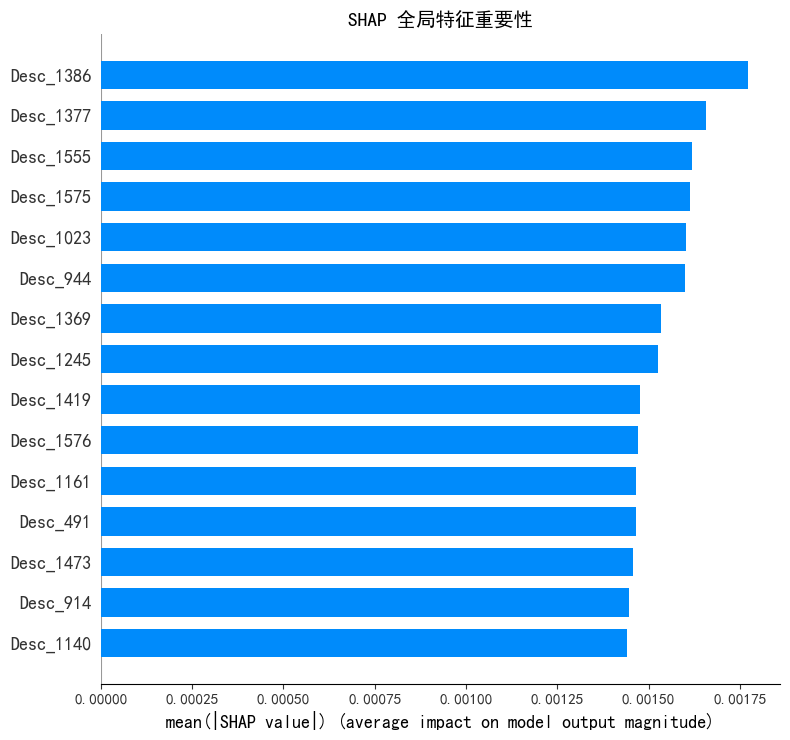

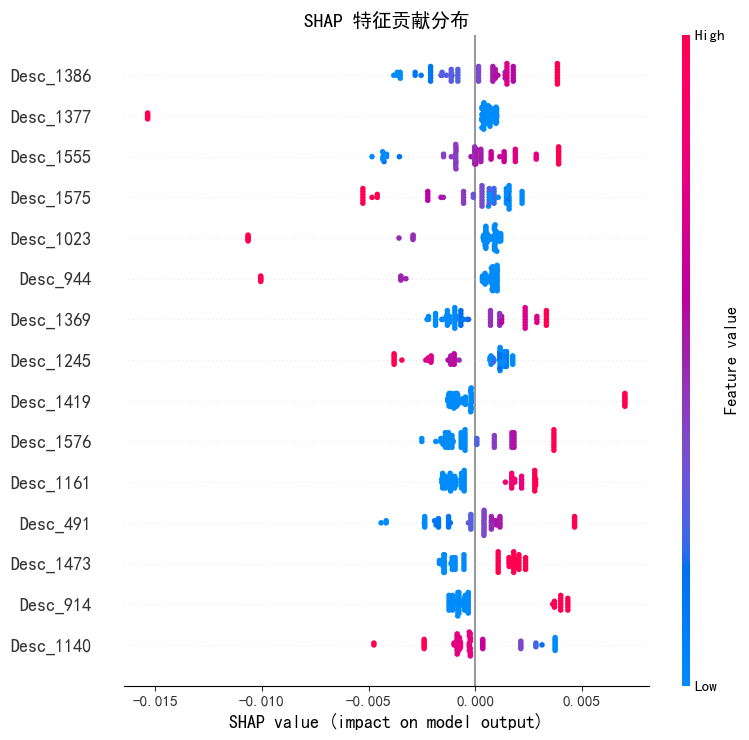


✅ SHAP 分析完成！前20个重要特征：
        Feature  Importance
1386  Desc_1386    0.001771
1377  Desc_1377    0.001658
1555  Desc_1555    0.001619
1575  Desc_1575    0.001612
1023  Desc_1023    0.001602
944    Desc_944    0.001599
1369  Desc_1369    0.001533
1245  Desc_1245    0.001526
1419  Desc_1419    0.001477
1576  Desc_1576    0.001470
1161  Desc_1161    0.001467
491    Desc_491    0.001464
1473  Desc_1473    0.001458
914    Desc_914    0.001446
1140  Desc_1140    0.001442
1550  Desc_1550    0.001440
1102  Desc_1102    0.001434
1330  Desc_1330    0.001388
1151  Desc_1151    0.001376
1301  Desc_1301    0.001369


In [10]:

# 步骤10：SHAP 特征重要性分析
# ------------------------------
print("\n📊 开始 SHAP 分析...")

# 直接使用测试集（已标准化）
shap_compound_features = X_test
shap_species_ids = sp_test

importance_df = shap_analysis_wrapper(
    model,
    shap_compound_features,
    shap_species_ids,
    species2id,
    device=device
)

In [10]:
# ==========================
# 步骤11：批量预测（最终版）
# ==========================
def batch_predict_excel(
    model,
    scaler,  # 必须传入标准化器
    input_excel_path,
    output_excel_path="AO1065Prob.xlsx",
    species2id=None,
    smiles_col="smiles",
    species_col="species",
    device="cpu"
):
    if species2id is None or not isinstance(species2id, dict):
        raise ValueError("必须提供有效的species2id字典")
    
    try:
        df = pd.read_excel(input_excel_path, engine="openpyxl")
        print(f"✅ 成功读取Excel，共 {len(df)} 条数据")
    except Exception as e:
        raise Exception(f"读取Excel失败：{e}")
    
    required_cols = [smiles_col, species_col]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"缺少列：{missing_cols}")
    
    print("\n🚀 开始批量预测...")
    toxicity_probs = []
    toxicity_labels = []
    error_indices = []
    
    for idx, row in df.iterrows():
        try:
            smiles = str(row[smiles_col]).strip()
            species = str(row[species_col]).strip()
            
            if smiles.lower() == "nan" or len(smiles) == 0:
                toxicity_probs.append(np.nan)
                toxicity_labels.append("无效SMILES")
                continue
            if species.lower() == "nan" or len(species) == 0:
                toxicity_probs.append(np.nan)
                toxicity_labels.append("无效物种")
                continue
            
            prob = predict_toxicity(
                model=model,
                smiles=smiles,
                species=species,
                species2id=species2id,
                scaler=scaler,
                device=device
            )
            
            toxicity_probs.append(round(prob, 4))
            toxicity_labels.append("有毒" if prob >= 0.5 else "无毒")
            
            if (idx + 1) % 50 == 0:
                print(f"进度：{idx+1}/{len(df)}")
        
        except Exception as e:
            toxicity_probs.append(np.nan)
            toxicity_labels.append("预测失败")
            error_indices.append(idx)
    
    df["毒性概率"] = toxicity_probs
    df["毒性判定"] = toxicity_labels
    
    df.to_excel(output_excel_path, index=False, engine="openpyxl")
    print(f"\n✅ 预测完成！结果已保存：{output_excel_path}")
    
    print("\n📊 预测统计：")
    print(f"总数：{len(df)}")
    print(f"有效：{len([p for p in toxicity_probs if not np.isnan(p)])}")
    print(f"有毒：{toxicity_labels.count('有毒')}")
    print(f"无毒：{toxicity_labels.count('无毒')}")
    
    print("\n🔍 前5条预览：")
    print(df[[smiles_col, species_col, "毒性概率", "毒性判定"]].head())

In [11]:
input_excel_path = "AO1065chemicalsmiles.xlsx"
output_excel_path = "AO1065Prob_model2.xlsx"

batch_predict_excel(
    model=model,                # 使用 model2
    scaler=scaler,               # 必须用训练时的scaler
    input_excel_path=input_excel_path,
    output_excel_path=output_excel_path,
    species2id=species2id,
    smiles_col="smiles",
    species_col="species",
    device=device
)

✅ 成功读取Excel，共 4282 条数据

🚀 开始批量预测...
进度：50/4282
进度：100/4282
进度：150/4282
进度：200/4282
进度：250/4282
进度：300/4282
进度：350/4282
进度：400/4282
进度：450/4282
进度：500/4282
进度：550/4282
进度：600/4282
进度：650/4282
进度：700/4282
进度：750/4282
进度：800/4282
进度：850/4282
进度：900/4282
进度：950/4282
进度：1000/4282
进度：1050/4282
进度：1100/4282
进度：1150/4282
进度：1200/4282
进度：1250/4282
进度：1300/4282
进度：1350/4282
进度：1400/4282
进度：1450/4282
进度：1500/4282
进度：1550/4282
进度：1600/4282
进度：1650/4282
进度：1700/4282
进度：1750/4282
进度：1800/4282
进度：1850/4282
进度：1900/4282
进度：1950/4282
进度：2000/4282
进度：2050/4282
进度：2100/4282
进度：2150/4282
进度：2200/4282
进度：2250/4282
进度：2300/4282
进度：2350/4282
进度：2400/4282
进度：2450/4282
进度：2500/4282
进度：2550/4282
进度：2600/4282
进度：2650/4282
进度：2700/4282
进度：2750/4282
进度：2800/4282
进度：2850/4282
进度：2900/4282
进度：2950/4282
进度：3000/4282
进度：3050/4282
进度：3100/4282
进度：3150/4282
进度：3200/4282
进度：3250/4282
进度：3300/4282
进度：3350/4282
进度：3400/4282
进度：3450/4282
进度：3500/4282
进度：3550/4282
进度：3600/4282
进度：3650/4282
进度：3700/4282
进度：3750/4282
进度：3800/4